In [1]:
import scanpy as sc

In [27]:
adata_ref = sc.read_h5ad('/Users/christoffer/work/karolinska/development/ST_BRICHOS/data/linnarsson_adolescence_full.h5ad')

/Users/christoffer/miniconda3/envs/cell2loc_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/Users/christoffer/miniconda3/envs/cell2loc_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [28]:
adata_ref.var.index = adata_ref.var.index.astype(str)

In [29]:
adata_ref.obs_names_make_unique()
adata_ref.var_names_make_unique()

/Users/christoffer/miniconda3/envs/cell2loc_env/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


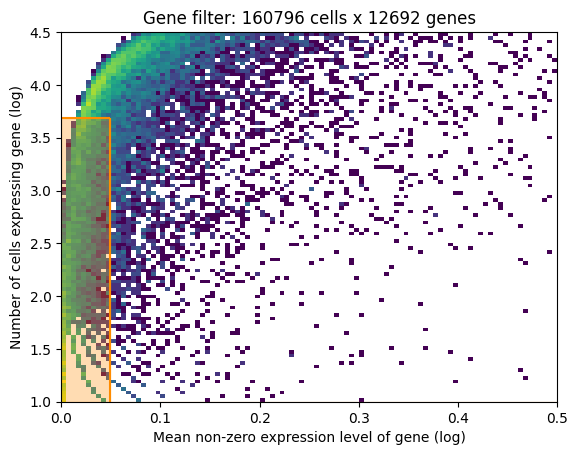

In [30]:
from cell2location.utils.filtering import filter_genes
selected = filter_genes(adata_ref, cell_count_cutoff=5, cell_percentage_cutoff2=0.03, nonz_mean_cutoff=1.12)

# filter the object
adata_ref = adata_ref[:, selected].copy()

In [31]:
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import cell2location

from matplotlib import rcParams
rcParams['pdf.fonttype'] = 42 # enables correct plotting of text for PDFs

In [32]:
adata_ref.obs

,Class,region_macro
CellID,,
10X82_2:TCTCTCACCAGTTA,Neurons,Enteric NS
10X82_2:TATTATCTACCAGA,Neurons,Enteric NS
10X82_2:TATCCCAGATGGCA,Neurons,Enteric NS
10X82_2:ATTACGTATGAATG,Neurons,Enteric NS
10X82_2:ATACGTCAATAAGG,Neurons,Enteric NS
...,...,...
10X43_2:GGTACAACAGTCGT,Neurons,DRG
10X43_2:TAATGATGGGTTAC,Neurons,DRG
10X43_2:CTGCAGCTTAGAGA,Neurons,DRG


In [33]:
# prepare anndata for the regression model
cell2location.models.RegressionModel.setup_anndata(adata=adata_ref,
                        # 10X reaction / sample / batch
                        # cell type, covariate used for constructing signatures
                        labels_key='Class',
                        # multiplicative technical effects (platform, 3' vs 5', donor effect)
                       )

In [34]:
results_folder = '../../results/lymph_nodes_analysis/'

# create paths and names to results folders for reference regression and cell2location models
ref_run_name = f'{results_folder}/reference_signatures'
run_name = f'{results_folder}/cell2location_map'

In [35]:
# create the regression model
from cell2location.models import RegressionModel
mod = RegressionModel(adata_ref)

# view anndata_setup as a sanity check
mod.view_anndata_setup()

Anndata setup with scvi-tools version 1.3.3.

Setup via `RegressionModel.setup_anndata` with arguments:

{
│   'layer': None,
│   'batch_key': None,
│   'labels_key': 'Class',
│   'categorical_covariate_keys': None,
│   'continuous_covariate_keys': None
}

         Summary Statistics          
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓
┃     Summary Stat Key     ┃ Value  ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩
│         n_batch          │   1    │
│         n_cells          │ 160796 │
│ n_extra_categorical_covs │   0    │
│ n_extra_continuous_covs  │   0    │
│         n_labels         │   7    │
│          n_vars          │ 12692  │
└──────────────────────────┴────────┘

               Data Registry                
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃    scvi-tools Location    ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      X       │          adata.X          │
│    batch     │ adata.obs['_scvi_batch']  │
│    ind_x     │   adata.obs['_indices']   │
│    labels    │ adata.obs['_scvi_labels'] │
└──────────────┴───────────────────────────┘

                     batch State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃     Source Location      ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['_scvi_batch'] │     0      │          0          │
└──────────────────────────┴────────────┴─────────────────────┘

                    labels State Registry                    
┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃  Source Location   ┃   Categories   ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['Class'] │   Astrocytes   │          0          │
│                    │   Ependymal    │          1          │
│                    │     Immune     │          2          │
│                    │    Neurons     │          3          │
│                    │     Oligos     │          4          │
│                    │ PeripheralGlia │          5          │
│                    │    Vascular    │          6          │
└────────────────────┴────────────────┴─────────────────────┘

In [40]:
import numpy as np
import pandas as pd
from scipy.sparse import issparse, csr_matrix

def ensure_counts_int_csr(A):
    if issparse(A.X):
        X = A.X.tocsr().astype(np.float32)
        if (X.data < 0).any():
            raise ValueError("Negative counts found.")
        if not np.isfinite(X.data).all():
            raise ValueError("NaN/inf in counts.")
        A.X = X
    else:
        X = np.asarray(A.X, dtype=np.float32)
        if (X < 0).any() or not np.isfinite(X).all():
            raise ValueError("Counts must be finite and >= 0.")
        A.X = csr_matrix(X)

def drop_empties(A, min_counts_cell=1, min_counts_gene=1):
    if issparse(A.X):
        cell_sum = np.array(A.X.sum(1)).ravel()
        gene_sum = np.array(A.X.sum(0)).ravel()
    else:
        cell_sum = A.X.sum(1)
        gene_sum = A.X.sum(0)
    A = A[cell_sum >= min_counts_cell, :]
    A = A[:, gene_sum >= min_counts_gene]
    return A

# Example for the reference AnnData you give to cell2location:
adata_ref = adata_ref.copy()  # or whatever you're using

ensure_counts_int_csr(adata_ref)
adata_ref = drop_empties(adata_ref, min_counts_cell=1, min_counts_gene=3)

# (Optional) cap extreme per-cell library sizes to reduce gradients exploding:
if issparse(adata_ref.X):
    lib = np.array(adata_ref.X.sum(1)).ravel()
else:
    lib = adata_ref.X.sum(1)
cap = np.quantile(lib, 0.999)
keep = lib <= cap
adata_ref = adata_ref[keep, :].copy()

In [43]:
# example: regression (reference) model
# mod = cell2location.models.RegressionModel(adata_ref, ...)
# IMPORTANT: smaller lr, big batch, CPU backend
mod.train(
    max_epochs=250,
    accelerator="cpu",
    batch_size=1024,     # or 2048 if RAM allows
    lr=0.002,            # smaller than default stabilizes ELBO
    check_val_every_n_epoch=0,
    enable_progress_bar=True,
)

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/christoffer/miniconda3/envs/cell2loc_env/lib/python3.10/site-packages/lightning/pytorch/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/Users/christoffer/miniconda3/envs/cell2loc_env/lib/python3.10/site-packages/lightning/pytorch/trainer/configuration_validator.py:68: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
/Users/christoffer/miniconda3/envs/cell2loc_env/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


ValueError: Expected parameter loc (Parameter of shape (1, 1)) of distribution Normal(loc: Parameter containing:
tensor([[nan]], requires_grad=True), scale: tensor([[nan]], grad_fn=<SoftplusBackward0>)) to satisfy the constraint Real(), but found invalid values:
Parameter containing:
tensor([[nan]], requires_grad=True)